In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


In [2]:
from glob import glob

def create_image_csv(base_dir="./data/processed_images"):
    filepaths = []
    labels = []

    for label_name in os.listdir(base_dir):
        label_path = os.path.join(base_dir, label_name)
        if not os.path.isdir(label_path):
            continue

        # Add real images
        for img_file in glob(os.path.join(label_path, "*.jpg")):
            filepaths.append(img_file)
            labels.append(label_name)

        # Add augmented images
        aug_path = os.path.join(label_path, "augmented")
        if os.path.exists(aug_path):
            for img_file in glob(os.path.join(aug_path, "*.jpg")):
                filepaths.append(img_file)
                labels.append(label_name)

    df = pd.DataFrame({"filepath": filepaths, "label": labels})
    df = df.sample(frac=1).reset_index(drop=True)  # Shuffle
    return df

df = create_image_csv()
df.to_csv("final_dataset.csv", index=False)
df.head()


,filepath,label
0,./data/processed_images\AKIEC\augmented\aug_46...,AKIEC
1,./data/processed_images\BCC\augmented\aug_6103...,BCC
2,./data/processed_images\AKIEC\augmented\aug_44...,AKIEC
3,./data/processed_images\MEL\augmented\aug_833.jpg,MEL
4,./data/processed_images\AKIEC\augmented\aug_25...,AKIEC


In [5]:
train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(64, 64),
    class_mode="categorical",
    batch_size=32
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(64, 64),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

num_classes = len(train_gen.class_indices)


Found 42241 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [6]:
def build_cnn(input_shape=(64, 64, 3), num_classes=7):
    model = models.Sequential()
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(256, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    return model

model = build_cnn(num_classes=num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\devgo\OneDrive\Desktop\project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,224,839 (19.93 MB)

 Trainable params: 5,223,943 (19.93 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8428 - loss: 0.4672

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 117s 88ms/step - accuracy: 0.8428 - loss: 0.4672 - val_accuracy: 0.7571 - val_loss: 0.6581
Epoch 2/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9128 - loss: 0.2543

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 208s 157ms/step - accuracy: 0.9128 - loss: 0.2543 - val_accuracy: 0.9101 - val_loss: 0.2578
Epoch 3/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 160s 121ms/step - accuracy: 0.9256 - loss: 0.2211 - val_accuracy: 0.9148 - val_loss: 0.2618
Epoch 4/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 202s 153ms/step - accuracy: 0.9242 - loss: 0.2269 - val_accuracy: 0.8481 - val_loss: 0.4135
Epoch 5/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 320s 197ms/step - accuracy: 0.9314 - loss: 0.2025 - val_accuracy: 0.7518 - val_loss: 0.5899
Epoch 6/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 300s 227ms/step - accuracy: 0.9369 - loss: 0.1858 - val_accuracy: 0.5439 - val_loss: 1.2620
Epoch 7/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 189s 143ms/step - accuracy: 0.9380 - loss: 0.1850 - val_accuracy: 0.4876 - val_loss: 3.1450
Epoch 8/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9427 - loss: 0.1767

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 114s 87ms/step - accuracy: 0.9427 - loss: 0.1767 - val_accuracy: 0.9161 - val_loss: 0.2531
Epoch 9/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9449 - loss: 0.1622

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9449 - loss: 0.1622 - val_accuracy: 0.9282 - val_loss: 0.1996
Epoch 10/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9461 - loss: 0.1655

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 116s 88ms/step - accuracy: 0.9461 - loss: 0.1655 - val_accuracy: 0.9399 - val_loss: 0.1911
Epoch 11/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9496 - loss: 0.1547

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 116s 88ms/step - accuracy: 0.9496 - loss: 0.1547 - val_accuracy: 0.9359 - val_loss: 0.1858
Epoch 12/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 160s 121ms/step - accuracy: 0.9507 - loss: 0.1479 - val_accuracy: 0.7103 - val_loss: 0.7822
Epoch 13/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9537 - loss: 0.1454

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 116s 88ms/step - accuracy: 0.9537 - loss: 0.1454 - val_accuracy: 0.9363 - val_loss: 0.1809
Epoch 14/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9554 - loss: 0.1393 - val_accuracy: 0.9384 - val_loss: 0.2666
Epoch 15/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9584 - loss: 0.1222 - val_accuracy: 0.9278 - val_loss: 0.2648
Epoch 16/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9596 - loss: 0.1296 - val_accuracy: 0.9384 - val_loss: 0.2122
Epoch 17/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9604 - loss: 0.1334 - val_accuracy: 0.9280 - val_loss: 0.2231
Epoch 18/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 311s 235ms/step - accuracy: 0.9664 - loss: 0.1069 - val_accuracy: 0.9421 - val_loss: 0.1996
Epoch 19/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 115s 87ms/step - accuracy: 0.9634 - loss: 0.1134 - val_accuracy: 0.9393 - val_loss: 0.2355
Epoch 20/50
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 117s 89ms/step - accuracy: 0.9

In [9]:
loss, acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {acc:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9327 - loss: 0.1893
✅ Validation Accuracy: 0.9363


147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
🔍 Classification Report:
               precision    recall  f1-score   support

       AKIEC     0.9984    0.9537    0.9756       670
         BCC     0.9968    0.9433    0.9693       670
         BKL     0.9862    0.8495    0.9127       671
          DF     1.0000    0.9911    0.9955       671
         MEL     0.9578    0.8465    0.8987       671
          NV     0.7143    0.9776    0.8255       670
        VASC     0.9985    0.9925    0.9955       671

    accuracy                         0.9363      4694
   macro avg     0.9503    0.9363    0.9390      4694
weighted avg     0.9503    0.9363    0.9390      4694



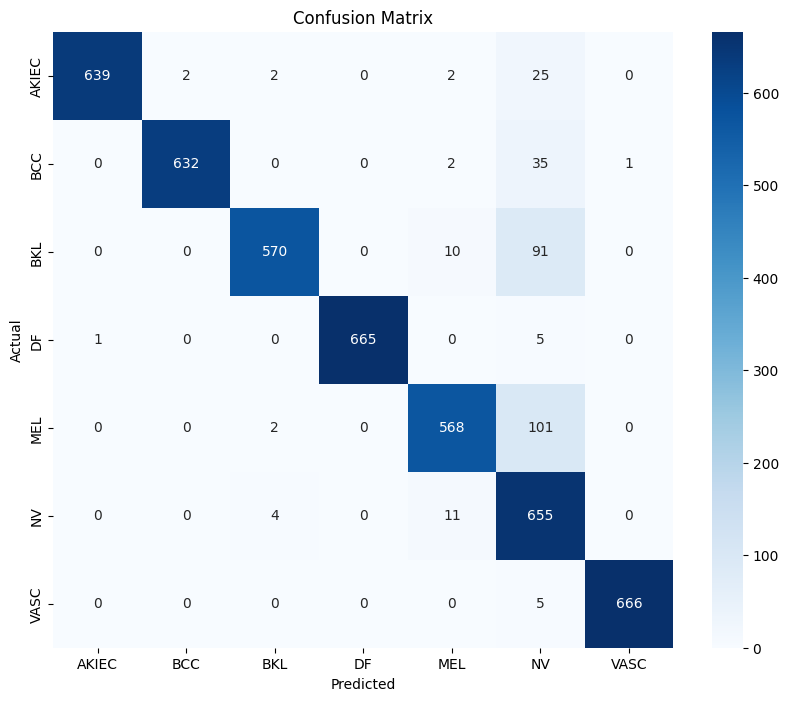

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True labels and predicted
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_labels = list(val_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("🔍 Classification Report:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
loss, acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {acc:.4f}")

model.save("cnn_skin_classifier.h5")


147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9327 - loss: 0.1893


✅ Validation Accuracy: 0.9363


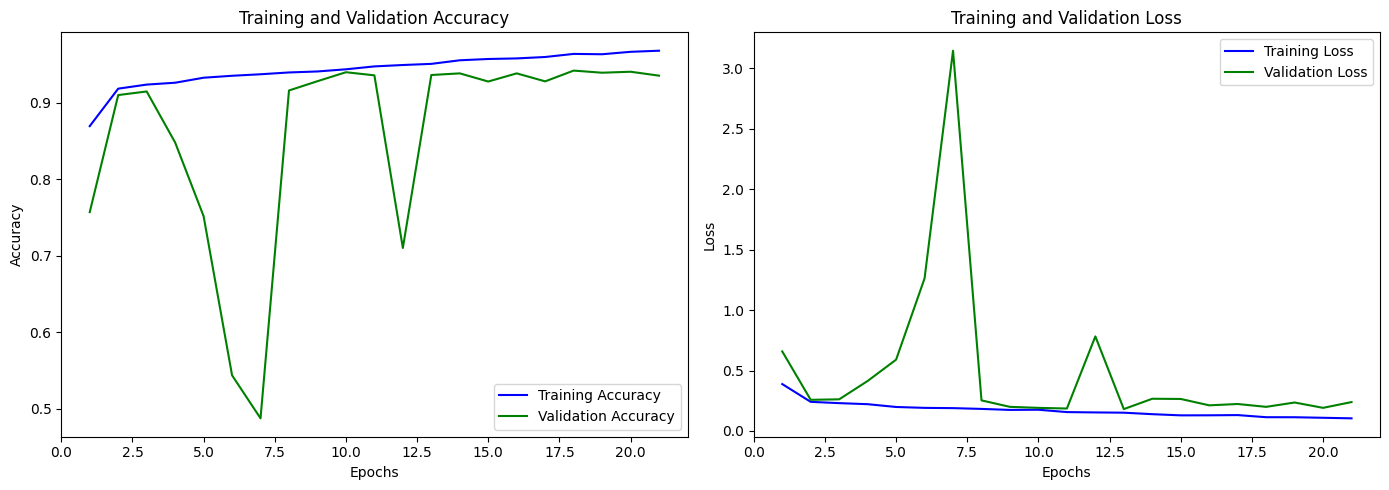

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'g-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call it after training
plot_training_history(history)


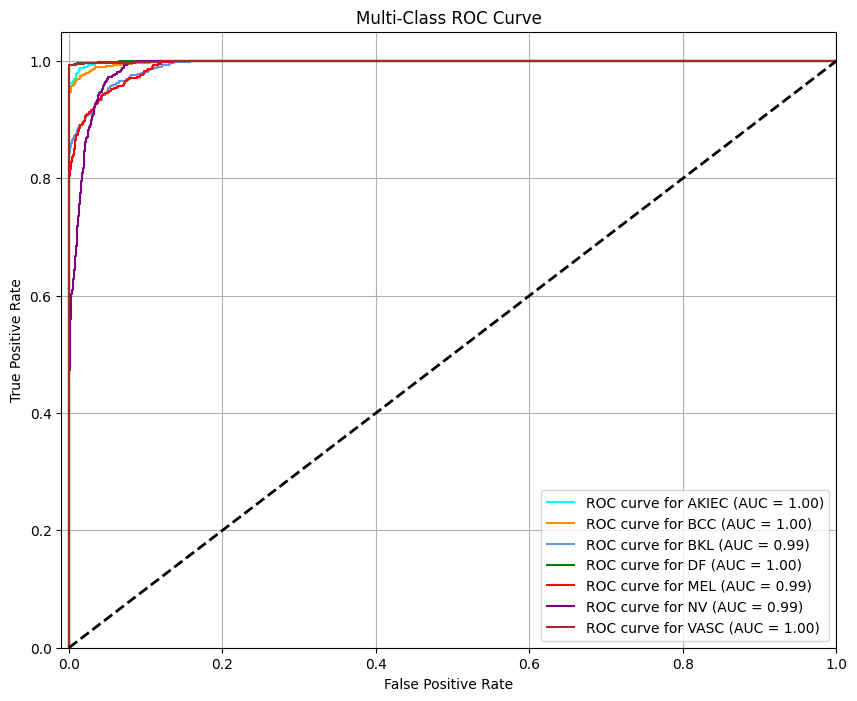

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from itertools import cycle

def plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels):
    n_classes = len(class_labels)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color,
                 label=f'ROC curve for {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Call this using:
plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels)


In [ ]:
import os
import numpy as np
from datetime import datetime
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.utils import to_categorical

def evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="MyModel", log_file="model_report.txt"):
    # Convert to class predictions
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.array(y_true)
    y_true_bin = to_categorical(y_true, num_classes=len(class_labels))

    # Get classification metrics
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4, output_dict=True)
    accuracy = report["accuracy"]
    f1 = report["weighted avg"]["f1-score"]
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    
    # Try ROC AUC
    try:
        roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')
        roc_auc_str = f"{roc_auc:.4f}"
    except:
        roc_auc_str = "N/A"

    # Create log string
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_entry = f"""
==========================
Timestamp : {timestamp}
Model     : {model_name}
Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC AUC   : {roc_auc_str}
==========================

"""

    # Append to text file (plain encoding)
    with open(log_file, "a") as f:
        f.write(log_entry)

    print("Model evaluation logged successfully.")
    print(log_entry)


In [38]:
# After training
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
class_labels = list(val_gen.class_indices.keys())

# Log model evaluation
evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="CNN")


147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step
Model evaluation logged successfully.

Timestamp : 2025-07-01 21:10:08
Model     : CNN
Accuracy  : 0.9363
Precision : 0.9503
Recall    : 0.9363
F1 Score  : 0.9390
ROC AUC   : 0.9963




In [47]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [58]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        [model.input],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [59]:
def display_gradcam(img_path, model, last_conv_layer_name, class_labels):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(64, 64))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    pred_label = class_labels[pred_class]

    heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    img_original = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM — Predicted: {pred_label}")
    plt.axis('off')
    plt.show()


In [51]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} - {layer.__class__.__name__}")


0: conv2d - Conv2D
1: batch_normalization - BatchNormalization
2: max_pooling2d - MaxPooling2D
3: conv2d_1 - Conv2D
4: batch_normalization_1 - BatchNormalization
5: max_pooling2d_1 - MaxPooling2D
6: conv2d_2 - Conv2D
7: batch_normalization_2 - BatchNormalization
8: max_pooling2d_2 - MaxPooling2D
9: flatten - Flatten
10: dense - Dense
11: dropout - Dropout
12: dense_1 - Dense
13: dropout_1 - Dropout
14: dense_2 - Dense


In [62]:
import os

def generate_gradcam_for_each_class(val_df, model, last_conv_layer_name, class_labels, output_dir="gradcam_outputs", samples_per_class=3):
    os.makedirs(output_dir, exist_ok=True)

    for class_name in class_labels:
        class_index = class_labels.index(class_name)
        class_df = val_df[val_df['label'] == class_name]

        print(f"\n📂 Generating Grad-CAMs for class: {class_name} ({len(class_df)} samples found)")
        class_output_path = os.path.join(output_dir, class_name)
        os.makedirs(class_output_path, exist_ok=True)

        selected_samples = class_df.sample(n=min(samples_per_class, len(class_df)), random_state=42)

        for i, row in selected_samples.iterrows():
            img_path = row['filepath']
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(64, 64))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0) / 255.0

            # Get predicted class
            preds = model.predict(img_array)
            pred_index = np.argmax(preds[0])
            heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index)

            # Build overlay
            heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
            img_original = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
            superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

            # Save overlay image
            filename = f"{class_name}_sample{i}.jpg"
            output_path = os.path.join(class_output_path, filename)
            cv2.imwrite(output_path, superimposed_img)
            print(f"✅ Saved Grad-CAM: {output_path}")


In [68]:
# Use this to get class labels in correct order
class_labels = list(val_gen.class_indices.keys())

# Ensure model is "built" by calling it on a sample input
sample_img_path = val_df.iloc[0]['filepath']
sample_img = tf.keras.preprocessing.image.load_img(sample_img_path, target_size=(64, 64))
sample_img_array = tf.keras.preprocessing.image.img_to_array(sample_img)
sample_img_array = np.expand_dims(sample_img_array, axis=0) / 255.0
_ = model.predict(sample_img_array)

generate_gradcam_for_each_class(
    val_df=val_df,
    model=model,
    last_conv_layer_name='conv2d_2',
    class_labels=class_labels,
    samples_per_class=3  # 🔁 Number of images per class
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step

📂 Generating Grad-CAMs for class: AKIEC (670 samples found)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


AttributeError: The layer sequential has never been called and thus has no defined input.